In [11]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from collections import Counter

pd.set_option('display.max_rows', 200)
sc.set_figure_params(figsize=(20, 4))
resultdir = './plots/'

In [2]:
# ============================================================
# Adjustable parameters
# ============================================================

# --- Perturbation filtering ---
n_de_threshold = 1          # min DE genes to keep a perturbation

# --- Variable gene selection (recurrent_de + hvg) ---
n_top_genes = 3000          # number of top HVGs
min_perturbations = 1       # gene must be DE in >= this many perturbations
de_adj_p_threshold = 0.1    # adj_p cutoff for recurrent DE gene counting

# --- HDBSCAN clustering ---
hdbscan_min_cluster_size = 3
hdbscan_min_samples = 1
hdbscan_cluster_selection = 'eom'  # 'eom' or 'leaf'

# --- Downstream gene analysis ---
de_threshold = 0.1          # adj_p_value threshold for downstream DE genes

# --- GO enrichment ---
go_padj_thres = 0.1         # adjusted p-value cutoff for GO terms
go_top_gene_num = 100       # min number of top downstream genes for enrichment
go_top_gene_frac = 0.03     # fraction of downstream genes (uses max of this and go_top_gene_num)
go_top_n_terms = 3          # max GO terms to plot per combination

## Load data

In [3]:
datadir = './'
adata_lps = sc.read_h5ad(datadir + '/DE_Mac_LPS_anndata.h5ad')
adata_ctrl = sc.read_h5ad(datadir + '/DE_Mac_Ctrl_anndata.h5ad')
print(f"LPS: {adata_lps.shape}, Ctrl: {adata_ctrl.shape}")

LPS: (567, 12403), Ctrl: (568, 12403)


## Prepare z-score matrix and mask on-target effects

In [4]:
def prepare_zscore(adata):
    """Compute z-scores and mask on-target knockdown effects."""
    adata.layers['zscore'] = adata.layers['log_fc'] / adata.layers['lfcSE']
    adata.layers['zscore'][np.where(adata.layers['zscore'] > 50)] = 50
    adata.layers['masked_zscore'] = adata.layers['zscore'].copy()
    for gene_id in set(adata.obs_names) & set(adata.var_names):
        adata.layers['masked_zscore'][adata.obs_names == gene_id, adata.var_names == gene_id] = 0
    adata.X = np.nan_to_num(adata.layers['masked_zscore'], 0).copy()
    return adata

adata_lps = prepare_zscore(adata_lps)
adata_ctrl = prepare_zscore(adata_ctrl)

## Filter perturbations by number of DE genes

        n_de_genes
count   567.000000
mean     30.058201
std     129.177632
min       0.000000
25%       0.000000
50%       1.000000
75%       1.000000
max    1313.000000

Total perturbations: 567


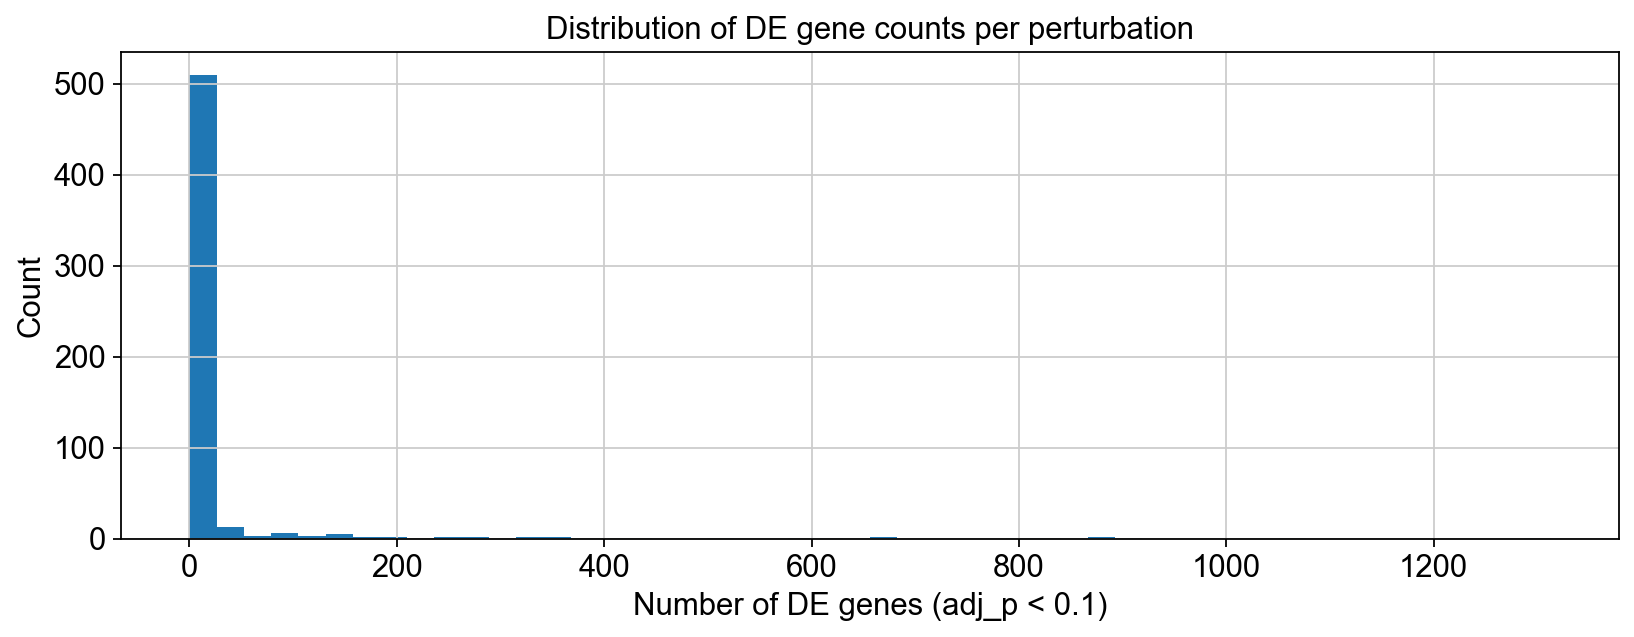

In [5]:
# Compute number of DE genes per perturbation
n_de_genes = np.array((adata_lps.layers['adj_p_value'] < 0.1).sum(axis=1)).flatten()
adata_lps.obs['n_de_genes'] = n_de_genes

print(adata_lps.obs[['contrast', 'n_de_genes']].describe())
print(f"\nTotal perturbations: {adata_lps.shape[0]}")

fig, ax = plt.subplots(figsize=(12, 4))
plt.hist(n_de_genes, bins=50)
plt.xlabel('Number of DE genes (adj_p < 0.1)')
plt.ylabel('Count')
plt.title('Distribution of DE gene counts per perturbation')
plt.show()

In [6]:
# Filter perturbations with >= n_de_threshold DE genes
mask = adata_lps.obs['n_de_genes'] >= n_de_threshold
adata_lps_filt = adata_lps[mask].copy()
adata_lps_filt.X = np.nan_to_num(adata_lps_filt.layers['masked_zscore'], 0).copy()
print(f"Perturbations passing (n_de_genes >= {n_de_threshold}): {adata_lps_filt.shape[0]} / {adata_lps.shape[0]}")
adata_lps_filt

Perturbations passing (n_de_genes >= 1): 303 / 567


AnnData object with n_obs × n_vars = 303 × 12403
    obs: 'contrast', 'condition', 'n_de_genes'
    layers: 'adj_p_value', 'baseMean', 'lfcSE', 'log_fc', 'p_value', 'zscore', 'masked_zscore'

## Variable gene filtering (recurrent_de + hvg)

Recurrent DE genes (adj_p < 0.1, in >= 1 perturbations): 5493
Top 3000 HVGs: 3000
Overlap: 2786
Union: 5707


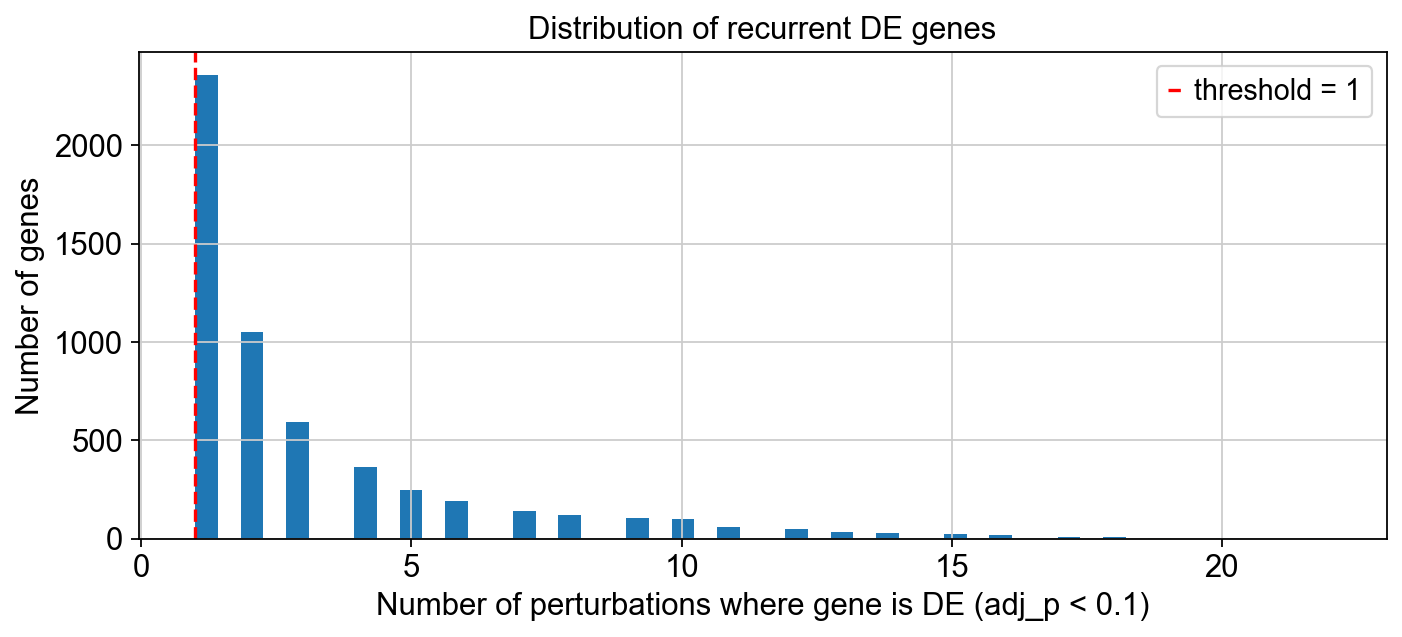


Final shape: (303, 5707)


In [7]:
# Recurrent DE genes: significantly DE in >= min_perturbations perturbations
n_sig_per_gene = np.array((adata_lps_filt.layers['adj_p_value'] < de_adj_p_threshold).sum(axis=0)).flatten()
de_mask = n_sig_per_gene >= min_perturbations

# Top N HVGs by variance of masked z-scores
gene_var = np.var(adata_lps_filt.X, axis=0)
var_cutoff = np.sort(gene_var)[::-1][min(n_top_genes - 1, len(gene_var) - 1)]
hvg_mask = gene_var >= var_cutoff

# Union
combined_mask = de_mask | hvg_mask
print(f"Recurrent DE genes (adj_p < {de_adj_p_threshold}, in >= {min_perturbations} perturbations): {de_mask.sum()}")
print(f"Top {n_top_genes} HVGs: {hvg_mask.sum()}")
print(f"Overlap: {(de_mask & hvg_mask).sum()}")
print(f"Union: {combined_mask.sum()}")

# Distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
plt.hist(n_sig_per_gene[n_sig_per_gene > 0], bins=50)
plt.axvline(min_perturbations, color='red', linestyle='--', label=f'threshold = {min_perturbations}')
plt.xlabel(f'Number of perturbations where gene is DE (adj_p < {de_adj_p_threshold})')
plt.ylabel('Number of genes')
plt.title('Distribution of recurrent DE genes')
plt.legend()
plt.show()

adata_lps_filt = adata_lps_filt[:, combined_mask].copy()
print(f"\nFinal shape: {adata_lps_filt.shape}")

## Perturbation correlation matrix

In [8]:
# Compute perturbation correlation matrix from masked z-scores
zscore_mat = np.nan_to_num(adata_lps_filt.layers['masked_zscore'], 0)
contrast_labels = list(adata_lps_filt.obs['contrast'].values)
zscore_df = pd.DataFrame(zscore_mat, index=contrast_labels, columns=adata_lps_filt.var_names)
corr_df = zscore_df.T.corr()

## HDBSCAN clustering on correlation matrix

In [9]:
# Convert correlation to distance and run HDBSCAN
dist_corr = np.clip(1 - corr_df.values, 0, 2)
np.fill_diagonal(dist_corr, 0)

clusterer = hdbscan.HDBSCAN(metric='precomputed',
                            min_cluster_size=hdbscan_min_cluster_size,
                            min_samples=hdbscan_min_samples,
                            cluster_selection_method=hdbscan_cluster_selection)
clusterer.fit(dist_corr)

hdbscan_labels = clusterer.labels_
adata_lps_filt.obs['hdbscan'] = hdbscan_labels
adata_lps_filt.obs['hdbscan'] = adata_lps_filt.obs['hdbscan'].astype('category')

n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()
print(f"HDBSCAN: {n_clusters} clusters, {n_noise} noise points ({adata_lps_filt.shape[0]} total)")
print(f"\nCluster sizes:")
for cl in sorted(set(hdbscan_labels)):
    label = f"  Cluster {cl}" if cl != -1 else "  Noise (-1)"
    print(f"{label}: {(hdbscan_labels == cl).sum()}")

HDBSCAN: 4 clusters, 253 noise points (303 total)

Cluster sizes:
  Noise (-1): 253
  Cluster 0: 5
  Cluster 1: 14
  Cluster 2: 28
  Cluster 3: 3


## Clustered correlation heatmap (LPS)

Plotting correlation matrix: (303, 303) (all 12403 genes)


/var/folders/qq/j023xkr13nxfrw65dx2bqwd00000gp/T/ipykernel_91900/170091101.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cl = plt.cm.get_cmap('tab20', n_cl)


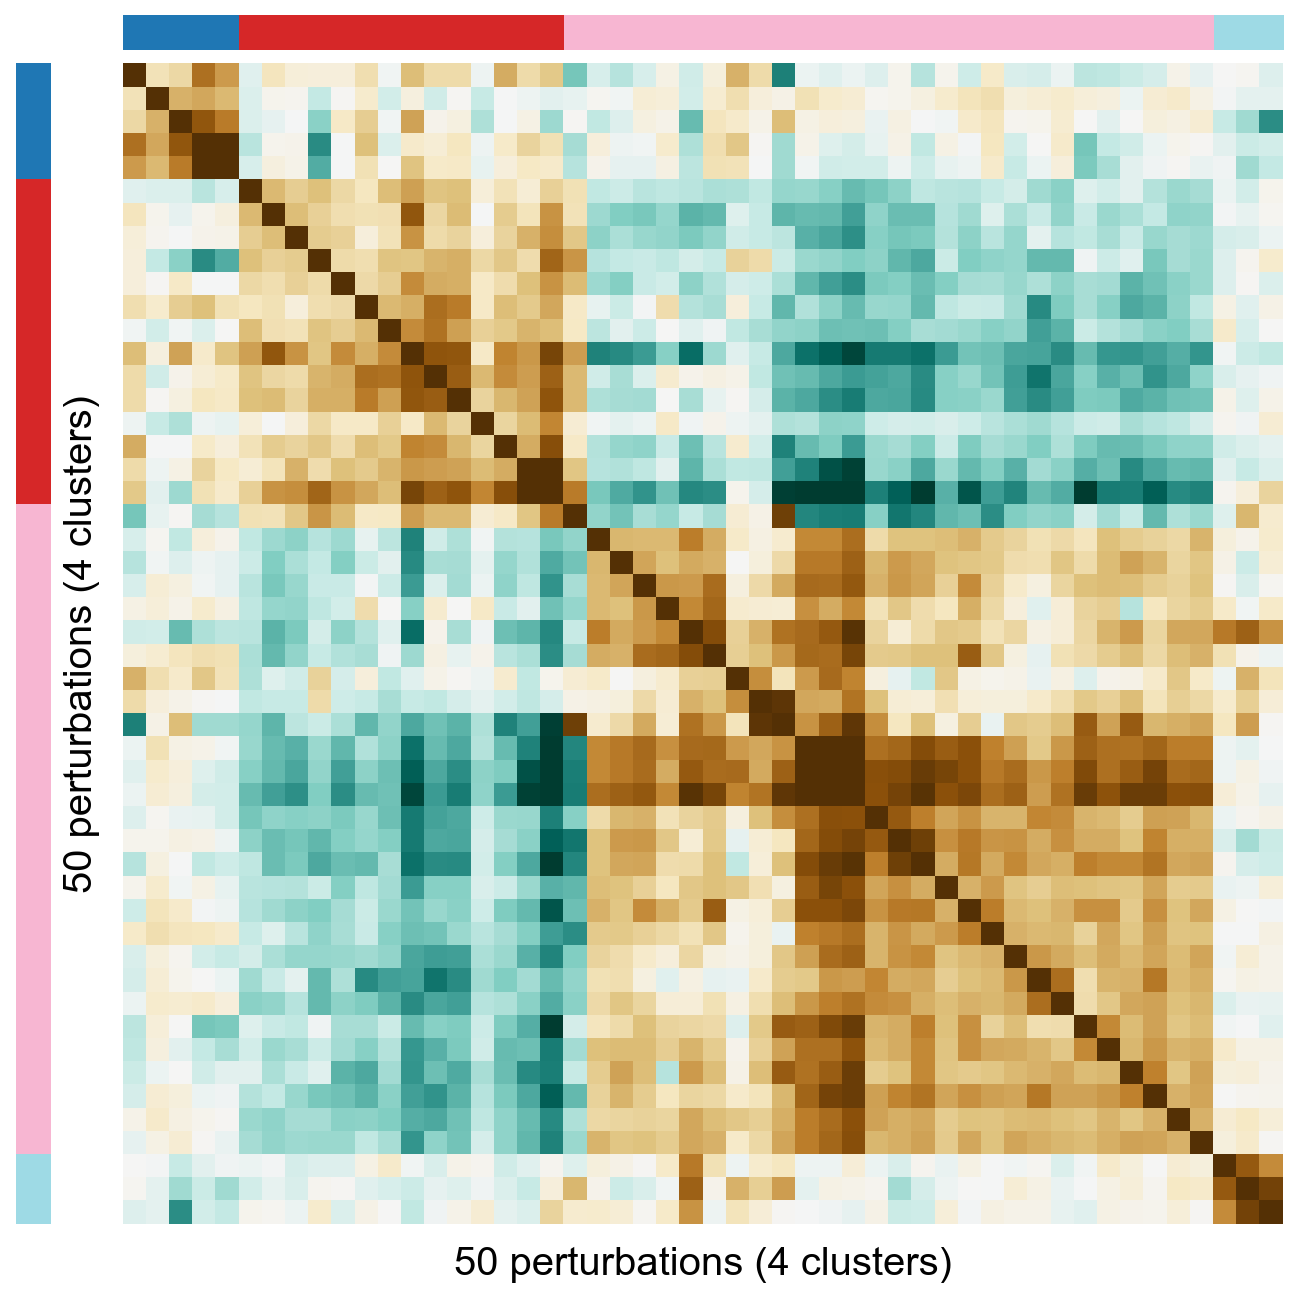

Clusters: [0, 1, 2, 3], mapping: {0: 0, 1: 1, 2: 2, 3: 3}


In [12]:
# Compute full-gene correlation matrix for plotting (all genes from adata_lps)
# HDBSCAN clustering was done on variable-filtered genes; this is only for visualization
lps_filt_mask = adata_lps.obs['contrast'].isin(contrast_labels)
adata_lps_allgenes = adata_lps[lps_filt_mask]
zscore_allgenes = np.nan_to_num(adata_lps_allgenes.layers['masked_zscore'], 0)
zscore_allgenes_df = pd.DataFrame(zscore_allgenes,
                                   index=list(adata_lps_allgenes.obs['contrast'].values),
                                   columns=adata_lps_allgenes.var_names)
# Ensure same order as contrast_labels
zscore_allgenes_df = zscore_allgenes_df.loc[contrast_labels]
corr_df_plot = zscore_allgenes_df.T.corr()
print(f"Plotting correlation matrix: {corr_df_plot.shape} (all {adata_lps.shape[1]} genes)")

# Order perturbations by HDBSCAN cluster with within-cluster hierarchical reordering
hdbscan_vals = adata_lps_filt.obs['hdbscan'].astype(int).values

ind_ordered = []
hdbscan_ordered = []

for cl in sorted(set(hdbscan_vals)):
    if cl == -1:
        continue
    cl_idx = np.where(hdbscan_vals == cl)[0]
    sub_corr = corr_df.values[np.ix_(cl_idx, cl_idx)]
    labels_cl = [contrast_labels[i] for i in cl_idx]
    if len(cl_idx) > 2:
        dist_cl = np.nan_to_num(pdist(sub_corr, metric='euclidean'), 0)
        link_cl = linkage(dist_cl, method='ward')
        order_cl = leaves_list(link_cl)
    else:
        order_cl = np.arange(len(cl_idx))
    for i in order_cl:
        ind_ordered.append(cl_idx[i])
        hdbscan_ordered.append(cl)

ind_ordered = np.array(ind_ordered)
hdbscan_ordered = np.array(hdbscan_ordered)

# Remap cluster IDs to consecutive integers for color bar
unique_cl = sorted(np.unique(hdbscan_ordered))
cl_to_idx = {cl: i for i, cl in enumerate(unique_cl)}
n_cl = len(unique_cl)
hdbscan_remapped = np.array([cl_to_idx[c] for c in hdbscan_ordered])

# Reorder full-gene correlation matrix for plotting
corr_ordered = corr_df_plot.values[np.ix_(ind_ordered, ind_ordered)]
labels_ordered = [contrast_labels[i] for i in ind_ordered]

# Plot
fig = plt.figure(figsize=(8, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[0.03, 1], height_ratios=[0.03, 1],
                      hspace=0.02, wspace=0.01)
ax_hm = fig.add_subplot(gs[1, 1])
ax_col = fig.add_subplot(gs[0, 1], sharex=ax_hm)
ax_row = fig.add_subplot(gs[1, 0], sharey=ax_hm)

thres = 0.3
sns.heatmap(pd.DataFrame(corr_ordered, index=labels_ordered, columns=labels_ordered),
            vmin=-thres, vmax=thres, cmap='BrBG_r', cbar=False,
            xticklabels=False, yticklabels=False, square=True, ax=ax_hm, rasterized=True)
ax_hm.set_xlabel(f'{len(ind_ordered)} perturbations ({n_cl} clusters)', fontsize=18, labelpad=10)
ax_hm.set_ylabel(f'{len(ind_ordered)} perturbations ({n_cl} clusters)', fontsize=18, labelpad=10)

cmap_cl = plt.cm.get_cmap('tab20', n_cl)
n = len(hdbscan_remapped)
ax_col.imshow([hdbscan_remapped], aspect='auto', cmap=cmap_cl,
              vmin=-0.5, vmax=n_cl - 0.5, extent=[0, n, 0, 1])
ax_col.set_xlim(0, n); ax_col.axis('off')
ax_row.imshow([[c] for c in hdbscan_remapped], aspect='auto', cmap=cmap_cl,
              vmin=-0.5, vmax=n_cl - 0.5, extent=[0, 1, n, 0])
ax_row.set_ylim(n, 0); ax_row.axis('off')

plt.savefig(resultdir + 'macs_hdbscan_correlation_heatmap.png', dpi=600, bbox_inches='tight')
plt.savefig(resultdir + 'macs_hdbscan_correlation_heatmap.pdf', dpi=600, bbox_inches='tight')
plt.show()
print(f"Clusters: {unique_cl}, mapping: {cl_to_idx}")

## Side-by-side: LPS vs Ctrl correlation (HDBSCAN cluster order)

Shared perturbations: 50, Clusters: 4


/var/folders/qq/j023xkr13nxfrw65dx2bqwd00000gp/T/ipykernel_91900/2804847473.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cl = plt.cm.get_cmap('tab20', n_cl)


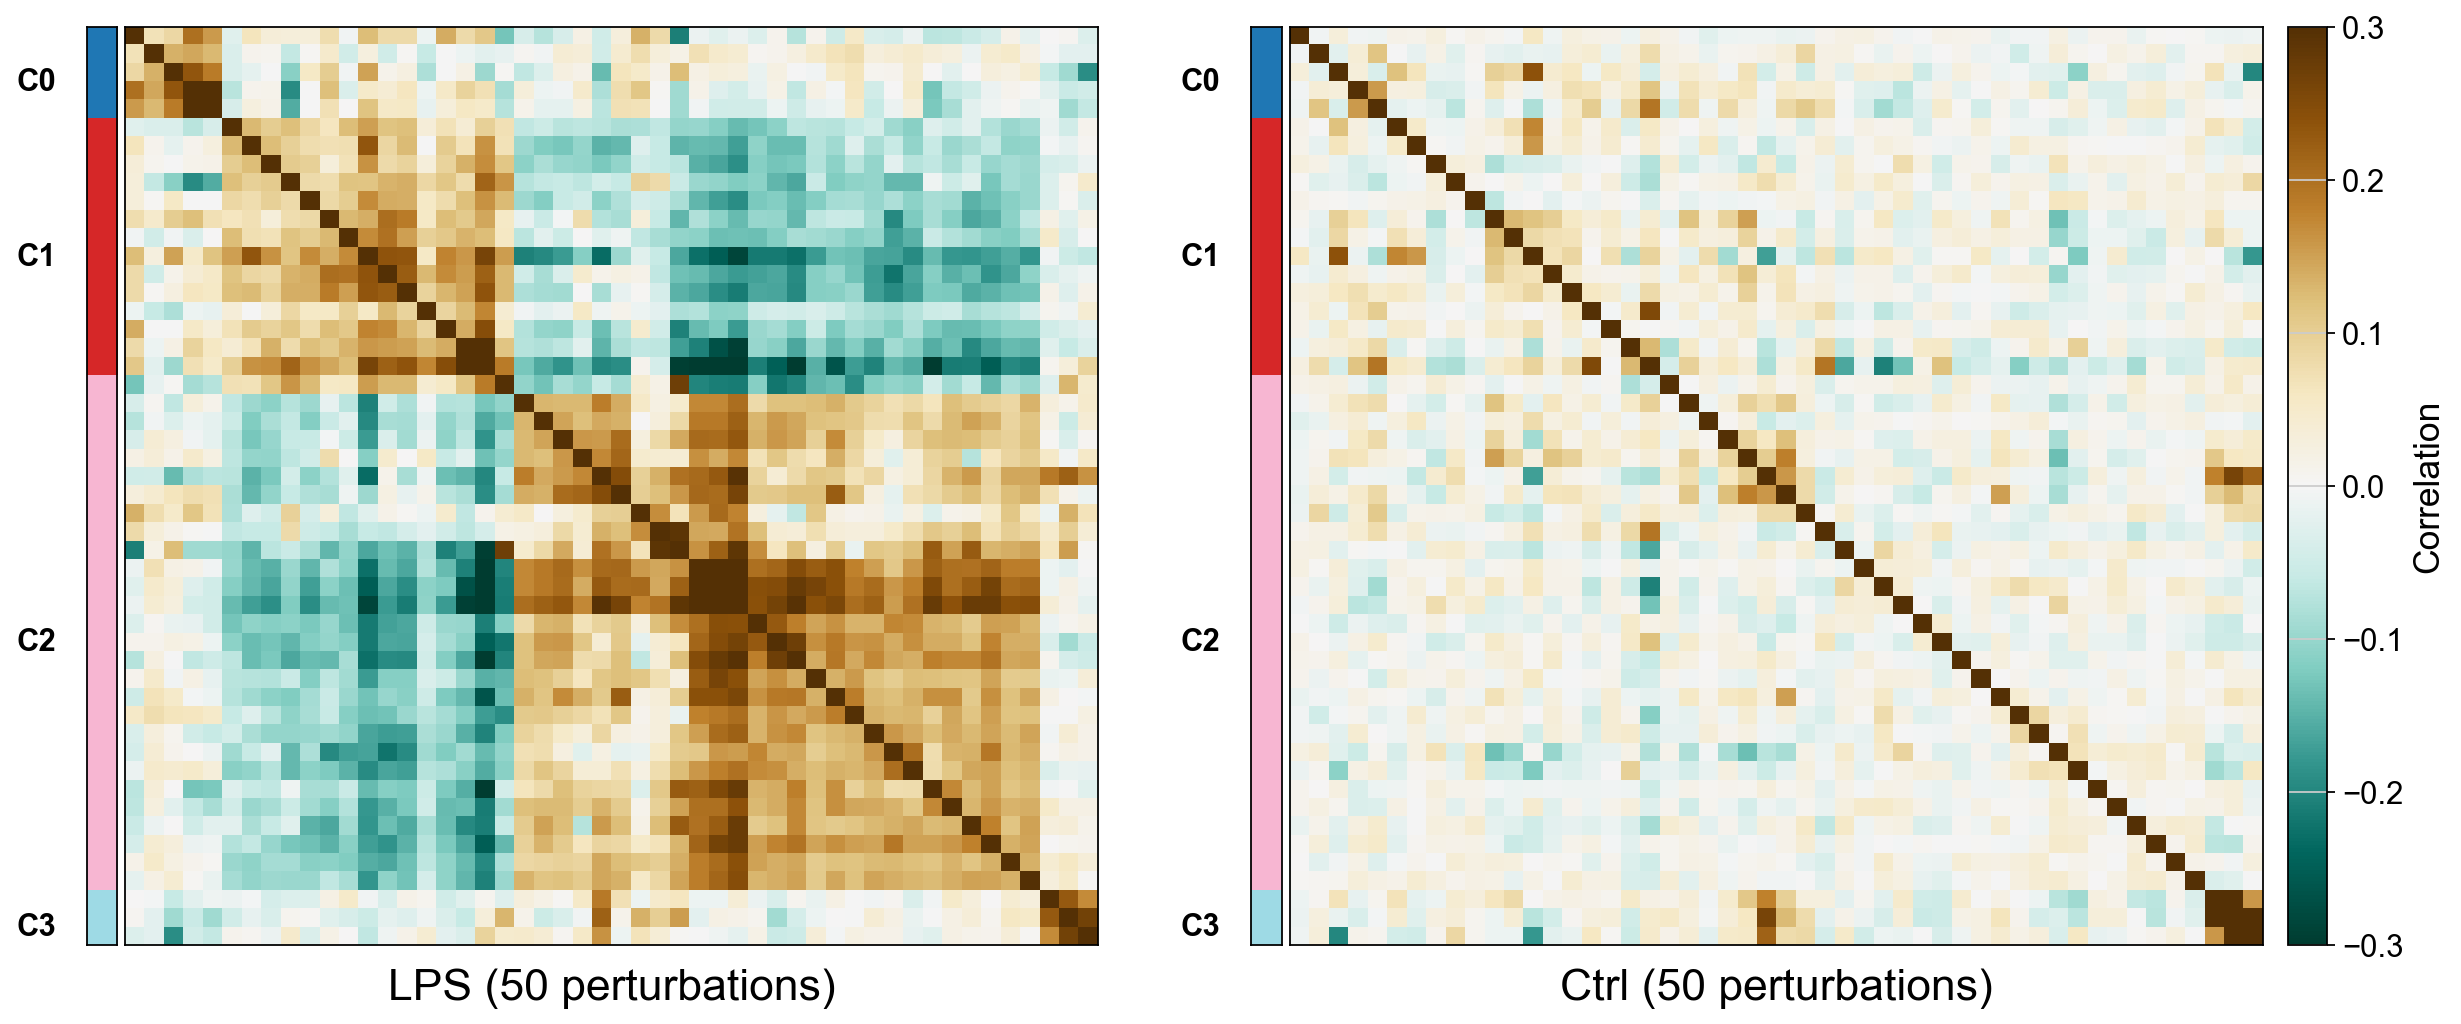

In [13]:
# Prepare Ctrl: compute full-gene correlation matrix for plotting
ctrl_contrasts_avail = set(adata_ctrl.obs['contrast'].values)
lps_contrasts_ordered = [contrast_labels[i] for i in ind_ordered]

# Find shared contrasts preserving LPS order
lps_keep = []
ctrl_reorder = []
hdbscan_shared = []
ctrl_contrast_to_idx = {c: i for i, c in enumerate(adata_ctrl.obs['contrast'].values)}

for i, c in enumerate(lps_contrasts_ordered):
    if c in ctrl_contrast_to_idx:
        lps_keep.append(i)
        ctrl_reorder.append(ctrl_contrast_to_idx[c])
        hdbscan_shared.append(hdbscan_ordered[i])

missing = [c for c in lps_contrasts_ordered if c not in ctrl_contrasts_avail]
if missing:
    print(f"Warning: {len(missing)} LPS contrasts not in Ctrl: {missing[:5]}...")

# Build Ctrl full-gene correlation matrix (all genes from adata_ctrl)
zscore_ctrl_all = np.nan_to_num(adata_ctrl.layers['masked_zscore'], 0)
ctrl_labels = list(adata_ctrl.obs['contrast'].values)
zscore_ctrl_all_df = pd.DataFrame(zscore_ctrl_all, index=ctrl_labels, columns=adata_ctrl.var_names)
corr_ctrl_plot = zscore_ctrl_all_df.T.corr()

# Reorder both to shared contrasts (using full-gene correlation matrices)
corr_lps_shared = corr_df_plot.values[np.ix_(ind_ordered[lps_keep], ind_ordered[lps_keep])]
corr_ctrl_shared = corr_ctrl_plot.values[np.ix_(ctrl_reorder, ctrl_reorder)]
hdbscan_shared = np.array(hdbscan_shared)
hdbscan_shared_remapped = np.array([cl_to_idx[c] for c in hdbscan_shared])

n_shared = len(lps_keep)
print(f"Shared perturbations: {n_shared}, Clusters: {n_cl}")

# --- Compute cluster boundaries for labels ---
cluster_boundaries = {}
for ci in range(n_cl):
    positions = np.where(hdbscan_shared_remapped == ci)[0]
    if len(positions) > 0:
        cluster_boundaries[ci] = (positions[0], positions[-1])

# --- Side-by-side plot using manual axes positioning ---
fig = plt.figure(figsize=(16, 7))

thres = 0.3
cmap_cl = plt.cm.get_cmap('tab20', n_cl)

# Manual positions: [left, bottom, width, height]
hm_w = 0.38
hm_h = 0.82
bar_w = 0.012
gap = 0.003
bottom = 0.1
panel_gap = 0.06

for panel_idx, (R_mat, title) in enumerate([
    (corr_lps_shared, 'LPS'),
    (corr_ctrl_shared, 'Ctrl'),
]):
    x0 = 0.06 + panel_idx * (bar_w + gap + hm_w + panel_gap)
    
    # Left color bar
    ax_row = fig.add_axes([x0, bottom, bar_w, hm_h])
    ax_row.imshow([[c] for c in hdbscan_shared_remapped], aspect='auto', cmap=cmap_cl,
                  vmin=-0.5, vmax=n_cl - 0.5, interpolation='nearest')
    ax_row.set_xticks([])
    ax_row.set_yticks([])
    # Cluster labels
    for ci, (start, end) in cluster_boundaries.items():
        mid = (start + end) / 2 + 0.5
        orig_cl = unique_cl[ci]
        ax_row.text(-1.0, mid, f'C{orig_cl}', ha='right', va='center',
                    fontsize=14, fontweight='bold', transform=ax_row.get_yaxis_transform())

    # Heatmap
    ax_hm = fig.add_axes([x0 + bar_w + gap, bottom, hm_w, hm_h])
    im = ax_hm.imshow(R_mat, vmin=-thres, vmax=thres, cmap='BrBG_r',
                      aspect='auto', interpolation='nearest')
    ax_hm.set_xticks([])
    ax_hm.set_yticks([])
    ax_hm.set_xlabel(f'{title} ({n_shared} perturbations)', fontsize=20, labelpad=10)

# Colorbar
ax_cbar = fig.add_axes([0.92, bottom, 0.015, hm_h])
cbar = fig.colorbar(im, cax=ax_cbar)
cbar.set_label('Correlation', fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.savefig(resultdir + 'macs_lps_vs_ctrl_hdbscan_correlation.png', dpi=600, bbox_inches='tight')
plt.savefig(resultdir + 'macs_lps_vs_ctrl_hdbscan_correlation.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [14]:
def print_cluster_info(adata, cluster_col='hdbscan', top_n_genes=10, cluster_id=None):
    clusters = sorted(adata.obs[cluster_col].unique())
    if cluster_id is not None:
        if isinstance(cluster_id, (int, np.integer)):
            cluster_id = [cluster_id]
        clusters = [c for c in clusters if c in cluster_id]
        if not clusters:
            print(f"No clusters found matching {cluster_id}")
            return
    print(f"Total perturbations: {adata.shape[0]}")
    all_cl = sorted(adata.obs[cluster_col].unique())
    print(f"Clusters: {len([c for c in all_cl if c != -1])}, Noise: {(adata.obs[cluster_col] == -1).sum()}")
    print("=" * 80)
    for cl in clusters:
        subset = adata[adata.obs[cluster_col] == cl]
        n = subset.shape[0]
        members = list(subset.obs['contrast'].values)
        mean_de = subset.obs['n_de_genes'].mean() if 'n_de_genes' in subset.obs else 0
        mean_abs_z = np.abs(np.nan_to_num(subset.layers['masked_zscore'], 0)).mean(axis=0)
        top_idx = np.argsort(mean_abs_z)[::-1][:top_n_genes]
        top_genes = [(subset.var_names[i], mean_abs_z[i]) for i in top_idx]
        label = f"Cluster {cl}" if cl != -1 else "Noise (-1)"
        print(f"\n{'─' * 80}")
        print(f"{label}  |  n={n}  |  mean DE genes: {mean_de:.1f}")
        print(f"  Members: {', '.join(members)}")
        print(f"  Top genes: {', '.join([f'{g} ({z:.2f})' for g, z in top_genes])}")

print_cluster_info(adata_lps_filt)

Total perturbations: 303
Clusters: 4, Noise: 253

────────────────────────────────────────────────────────────────────────────────
Noise (-1)  |  n=253  |  mean DE genes: 17.6
  Members: AAGAB, ABCF1, ACP5, AGPAT1, AHR, AKT1, AP1AR, AP3B1, AQP11, ARPC4, ATF6B, ATP5D, ATP6AP1, ATP6V1B2, AXL, B4GALT1, BCL3, BCL9L, BPTF, BRD2, BRD7, BTK, BUD13, C1GALT1C1L, C1orf141, C2, C3, C5, C6orf47, CASP4, CBFB, CBX7, CCDC174, CCNG1, CCR6, CD19, CD36, CD38, CD40, CD47, CFD, CFH, CHUK, CIITA, CLIC1, CR1, CREB1, CRIPAK, CRK, CSF2RB, CSNK1A1, CTCF, CTNND1, CTR9, CTSB, CTSZ, CXCR4, CYBA, CYBB, DDAH2, DDOST, DDX18, DGKA, DHX15, DLEC1, DMAP1, DOCK8, DPP10, DRAP1, EFR3A, EIF2AK2, EIF5, ETS2, FADD, FAM50A, FGF12, FLI1, FLOT1, FOS, FOXF1, G6PC3, G6PD, GHITM, GNAS, GPR183, GPSM3, GPX4, GSDMB, GSDMC, GSDMD, GYPC, HAT1, HAX1, HDAC3, HIF1A, HSP90B1, HSPA1B, HSPD1, ICAM1, IDO1, IFI30, IFNAR1, IFNGR2, IKBKB, IKZF1, IL1B, IL2RA, IL2RG, IRF5, IRF7, ITGAL, ITGB2, ITPA, JAGN1, JAK2, JUN, JUNB, KAT2A, KAT5, KIDINS220, KI